# Task 4 & 5 — CNN-based LULC Classification and Accuracy Assessment

**Study Area:** Rhine Gorge (Mittelrheintal), Germany
**Input:** Landsat 8 bands B2–B7 + NDVI (7 channels)
**Ground truth:** ESRI 10 m LULC (ArcGIS Living Atlas) resampled to 30 m

A patch-based CNN is trained on 7×7 pixel neighbourhoods centred on labelled pixels.
Spatial context helps distinguish vineyard terraces (structured rows) from forest (homogeneous canopy).

| Channel | Band | Wavelength | Role |
|---------|------|-----------|------|
| 1 | B2 Blue  | 0.45–0.51 µm | Water penetration, urban |
| 2 | B3 Green | 0.53–0.59 µm | Vegetation peak |
| 3 | B4 Red   | 0.64–0.67 µm | Chlorophyll absorption |
| 4 | B5 NIR   | 0.85–0.88 µm | Biomass, vegetation structure |
| 5 | B6 SWIR1 | 1.57–1.65 µm | Soil moisture, geology |
| 6 | B7 SWIR2 | 2.11–2.29 µm | Rock / bare soil discrimination |
| 7 | NDVI     | derived      | Vegetation density index |

**Split strategy:** Spatial block split (10×10 px blocks ≈ 300 m) → 70% train / 15% val / 15% test.
Random pixel splits cause spatial autocorrelation leakage, inflating accuracy artificially.


In [1]:
!pip install torch torchvision scikit-learn rasterio numpy matplotlib shapely scipy --quiet

In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.crs import CRS
from rasterio.warp import transform_bounds, transform_geom
from rasterio.windows import from_bounds
from rasterio.mask import mask as rio_mask
from shapely.geometry import box, mapping, shape
from scipy.ndimage import zoom as ndimage_zoom

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score, jaccard_score)
from sklearn.preprocessing import label_binarize

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## Step 1 — Load config

In [3]:
CONFIG_PATH = '../data/landsat/band_paths.json'

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

aoi         = cfg['aoi']
AOI_MIN_LON = aoi['min_lon'];  AOI_MAX_LON = aoi['max_lon']
AOI_MIN_LAT = aoi['min_lat'];  AOI_MAX_LAT = aoi['max_lat']
AREA_KM2    = aoi['area_km2'];  SCENE_ID   = cfg['scene_id']

BAND2_BLUE  = cfg['band2_blue'];  BAND3_GREEN = cfg['band3_green']
BAND4_RED   = cfg['band4_red'];   BAND5_NIR   = cfg['band5_nir']
BAND6_SWIR1 = cfg['band6_swir1']; BAND7_SWIR2 = cfg['band7_swir2']
LULC_PATH   = cfg['esri_lulc']['clipped_to_landsat']
NDVI_PATH   = cfg['ndvi']['tif_path']
OUTPUTS_DIR = '../data/outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'Scene : {SCENE_ID}')
print(f'LULC  : {"OK" if os.path.exists(LULC_PATH) else "MISSING — run NB2 first"}')
print(f'NDVI  : {"OK" if os.path.exists(NDVI_PATH) else "MISSING — run NB3 first"}')

Scene : LC81960252021153LGN00
LULC  : OK
NDVI  : OK


## Step 2 — Load and stack all 7 input bands

In [4]:
def load_band_clipped(filepath, min_lon, min_lat, max_lon, max_lat):
    """Load Landsat C2 L2 band with shapely AOI intersection (crash-safe)."""
    aoi_wgs84 = box(min_lon, min_lat, max_lon, max_lat)
    with rasterio.open(filepath) as src:
        aoi_native  = shape(transform_geom('EPSG:4326', src.crs.to_wkt(), mapping(aoi_wgs84)))
        raster_bbox = box(*src.bounds)
        aoi_safe    = aoi_native.intersection(raster_bbox)
        if aoi_safe.is_empty:
            raise ValueError(f'AOI does not overlap raster: {filepath}')
        clipped, _    = rio_mask(src, [mapping(aoi_safe)], crop=True, nodata=0)
        raw           = clipped[0].astype(np.float32)
        left, bottom, right, top = transform_bounds(
            CRS.from_epsg(4326), src.crs, min_lon, min_lat, max_lon, max_lat)
        win_transform = src.window_transform(from_bounds(left, bottom, right, top, src.transform))
        crs_out       = src.crs
    fill_mask   = (raw < 7273) | (raw > 65455)
    reflectance = np.clip(raw * 0.0000275 - 0.2, 0.0, 1.0)
    reflectance[fill_mask] = np.nan
    return reflectance, win_transform, crs_out

b2, TRANSFORM, CRS_UTM = load_band_clipped(BAND2_BLUE,  AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
b3, _, _ = load_band_clipped(BAND3_GREEN, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
b4, _, _ = load_band_clipped(BAND4_RED,   AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
b5, _, _ = load_band_clipped(BAND5_NIR,   AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
b6, _, _ = load_band_clipped(BAND6_SWIR1, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
b7, _, _ = load_band_clipped(BAND7_SWIR2, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)

# Band shape safety trim
bands_list = [b2, b3, b4, b5, b6, b7]
shapes = [b.shape for b in bands_list]
if len(set(shapes)) > 1:
    min_r = min(s[0] for s in shapes); min_c = min(s[1] for s in shapes)
    bands_list = [b[:min_r, :min_c] for b in bands_list]
    b2, b3, b4, b5, b6, b7 = bands_list
    print(f'Bands trimmed to {min_r}×{min_c}')

with rasterio.open(NDVI_PATH) as src:
    ndvi = src.read(1).astype(np.float32)
ndvi[ndvi == -9999.0] = np.nan

BAND_STACK = np.dstack([b2, b3, b4, b5, b6, b7, ndvi])
N_CHANNELS = BAND_STACK.shape[2]
print(f'Band stack: {BAND_STACK.shape}  (rows × cols × {N_CHANNELS} channels)')

Band stack: (242, 242, 7)  (rows × cols × 7 channels)


## Step 3 — Load ESRI LULC ground truth

In [5]:
CLASS_MAP = {
    1:  ('Water',             '#1A5BAB', 0),   # Rhine River
    2:  ('Trees',             '#358221', 1),   # forested valley slopes
    5:  ('Crops / Vineyards', '#FFDB5C', 2),   # plateau agriculture & terraces
    7:  ('Built area',        '#ED022A', 3),   # towns + cliff faces
    11: ('Rangeland',         '#E8D44D', 4),   # open grassland / meadow
}
N_CLASSES   = len(CLASS_MAP)
CLASS_NAMES = [CLASS_MAP[k][0] for k in sorted(CLASS_MAP)]
CLASS_COLORS= [CLASS_MAP[k][1] for k in sorted(CLASS_MAP)]

with rasterio.open(LULC_PATH) as src:
    lulc_raw = src.read(1)

lulc_labels = np.full(lulc_raw.shape, -1, dtype=np.int8)
for esri_code, (_, _, label) in CLASS_MAP.items():
    lulc_labels[lulc_raw == esri_code] = label

# Resize LULC to Landsat grid (nearest-neighbour, preserves class IDs)
if lulc_labels.shape != b4.shape:
    scale_r = b4.shape[0] / lulc_labels.shape[0]
    scale_c = b4.shape[1] / lulc_labels.shape[1]
    lulc_labels = ndimage_zoom(lulc_labels.astype(np.float32),
                               (scale_r, scale_c), order=0).astype(np.int8)
    min_r = min(b4.shape[0], lulc_labels.shape[0])
    min_c = min(b4.shape[1], lulc_labels.shape[1])
    lulc_labels = lulc_labels[:min_r, :min_c]
    print(f'LULC resampled to Landsat grid: {lulc_labels.shape}')
else:
    print(f'LULC shape matches Landsat: {lulc_labels.shape}')

print(f'\n{"Label":<6} {"Class":<22} {"Pixels":>8} {"Cover"}')
print('─' * 45)
for esri_code, (name, _, label) in CLASS_MAP.items():
    count = np.sum(lulc_labels == label)
    pct   = 100 * count / max(np.sum(lulc_labels >= 0), 1)
    print(f'{label:<6} {name:<22} {count:>8,}   {pct:.1f}%')


LULC resampled to Landsat grid: (242, 242)

Label  Class                    Pixels Cover
─────────────────────────────────────────────
0      Water                     3,284   5.8%
1      Trees                    22,005   38.6%
2      Crops / Vineyards        23,644   41.4%
3      Built area                5,248   9.2%
4      Rangeland                 2,874   5.0%


## Step 4 — Spatial block split and patch extraction  *(Assessment 4a)*

AOI divided into 10×10 pixel blocks (~300 m × 300 m). Whole blocks assigned to
**train (70%) / val (15%) / test (15%)** — this prevents spatial autocorrelation
leakage where adjacent pixels appear in both train and test sets.


In [ ]:
PATCH_SIZE = 7
HALF       = PATCH_SIZE // 2
MAX_PIXELS = 3000   # per class — kept moderate to avoid trivial accuracy
BLOCK_SIZE = 10     # 10×10 pixel blocks ≈ 300 m × 300 m at 30 m resolution

#  Spatial block split (prevents autocorrelation leakage)
rows, cols = lulc_labels.shape
block_row  = np.arange(rows) // BLOCK_SIZE
block_col  = np.arange(cols) // BLOCK_SIZE
block_id   = block_row[:, None] * (cols // BLOCK_SIZE + 1) + block_col[None, :]

unique_blocks = np.unique(block_id)
np.random.seed(SEED)
np.random.shuffle(unique_blocks)

n         = len(unique_blocks)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_blocks = set(unique_blocks[:train_end].tolist())
val_blocks   = set(unique_blocks[train_end:val_end].tolist())
test_blocks  = set(unique_blocks[val_end:].tolist())

train_mask = np.isin(block_id, list(train_blocks)) & (lulc_labels >= 0)
val_mask   = np.isin(block_id, list(val_blocks))   & (lulc_labels >= 0)
test_mask  = np.isin(block_id, list(test_blocks))  & (lulc_labels >= 0)

print(f'Block split — Train: {train_mask.sum():,} | Val: {val_mask.sum():,} | Test: {test_mask.sum():,} pixels')

#  Extract patches from each split independently 
stack_padded = np.pad(BAND_STACK, ((HALF, HALF), (HALF, HALF), (0, 0)), mode='reflect')

def extract_patches(mask, max_per_class):
    patches_, labels_, coords_ = [], [], []
    for label_id in range(N_CLASSES):
        class_mask = mask & (lulc_labels == label_id)
        ys, xs = np.where(class_mask)
        valid  = ~np.isnan(BAND_STACK[ys, xs, :]).any(axis=1)
        ys, xs = ys[valid], xs[valid]
        if len(ys) > max_per_class:
            idx = np.random.choice(len(ys), max_per_class, replace=False)
            ys, xs = ys[idx], xs[idx]
        for y, x in zip(ys, xs):
            patches_.append(stack_padded[y:y + PATCH_SIZE, x:x + PATCH_SIZE, :])
            labels_.append(label_id)
            coords_.append((y, x))
    return (np.array(patches_, dtype=np.float32),
            np.array(labels_,  dtype=np.int64),
            np.array(coords_))

X_train_raw, y_train, c_train = extract_patches(train_mask, MAX_PIXELS)
X_val_raw,   y_val,   c_val   = extract_patches(val_mask,   MAX_PIXELS // 2)
X_test_raw,  y_test,  c_test  = extract_patches(test_mask,  MAX_PIXELS // 2)

#  Normalise using TRAIN statistics only
CHANNEL_MEAN = np.nanmean(X_train_raw, axis=(0, 1, 2))
CHANNEL_STD  = np.nanstd( X_train_raw, axis=(0, 1, 2))
CHANNEL_STD[CHANNEL_STD == 0] = 1.0

def normalise(patches):
    return np.nan_to_num((patches - CHANNEL_MEAN) / CHANNEL_STD, nan=0.0)

X_train = normalise(X_train_raw)
X_val   = normalise(X_val_raw)
X_test  = normalise(X_test_raw)

print(f'\nPatch counts after spatial block split:')
print(f'  Train : {len(X_train):,}  ({len(X_train)/len(X_train)*100:.0f}%)')
print(f'  Val   : {len(X_val):,}')
print(f'  Test  : {len(X_test):,}')

# Sanity check — no coordinate overlap between train and test
train_set = set(map(tuple, c_train.tolist()))
test_set  = set(map(tuple, c_test.tolist()))
overlap   = len(train_set & test_set)
print(f'  Train/test coordinate overlap: {overlap} (must be 0)')


Block split — Train: 39,198 | Val: 9,138 | Test: 8,719 pixels

Patch counts after spatial block split:
  Train : 12,802  (100%)
  Val   : 4,392
  Test  : 5,163
  Train/test coordinate overlap: 0 (must be 0)


## Step 5 — Display training and test patches on Landsat  *(Assessment 4a)*

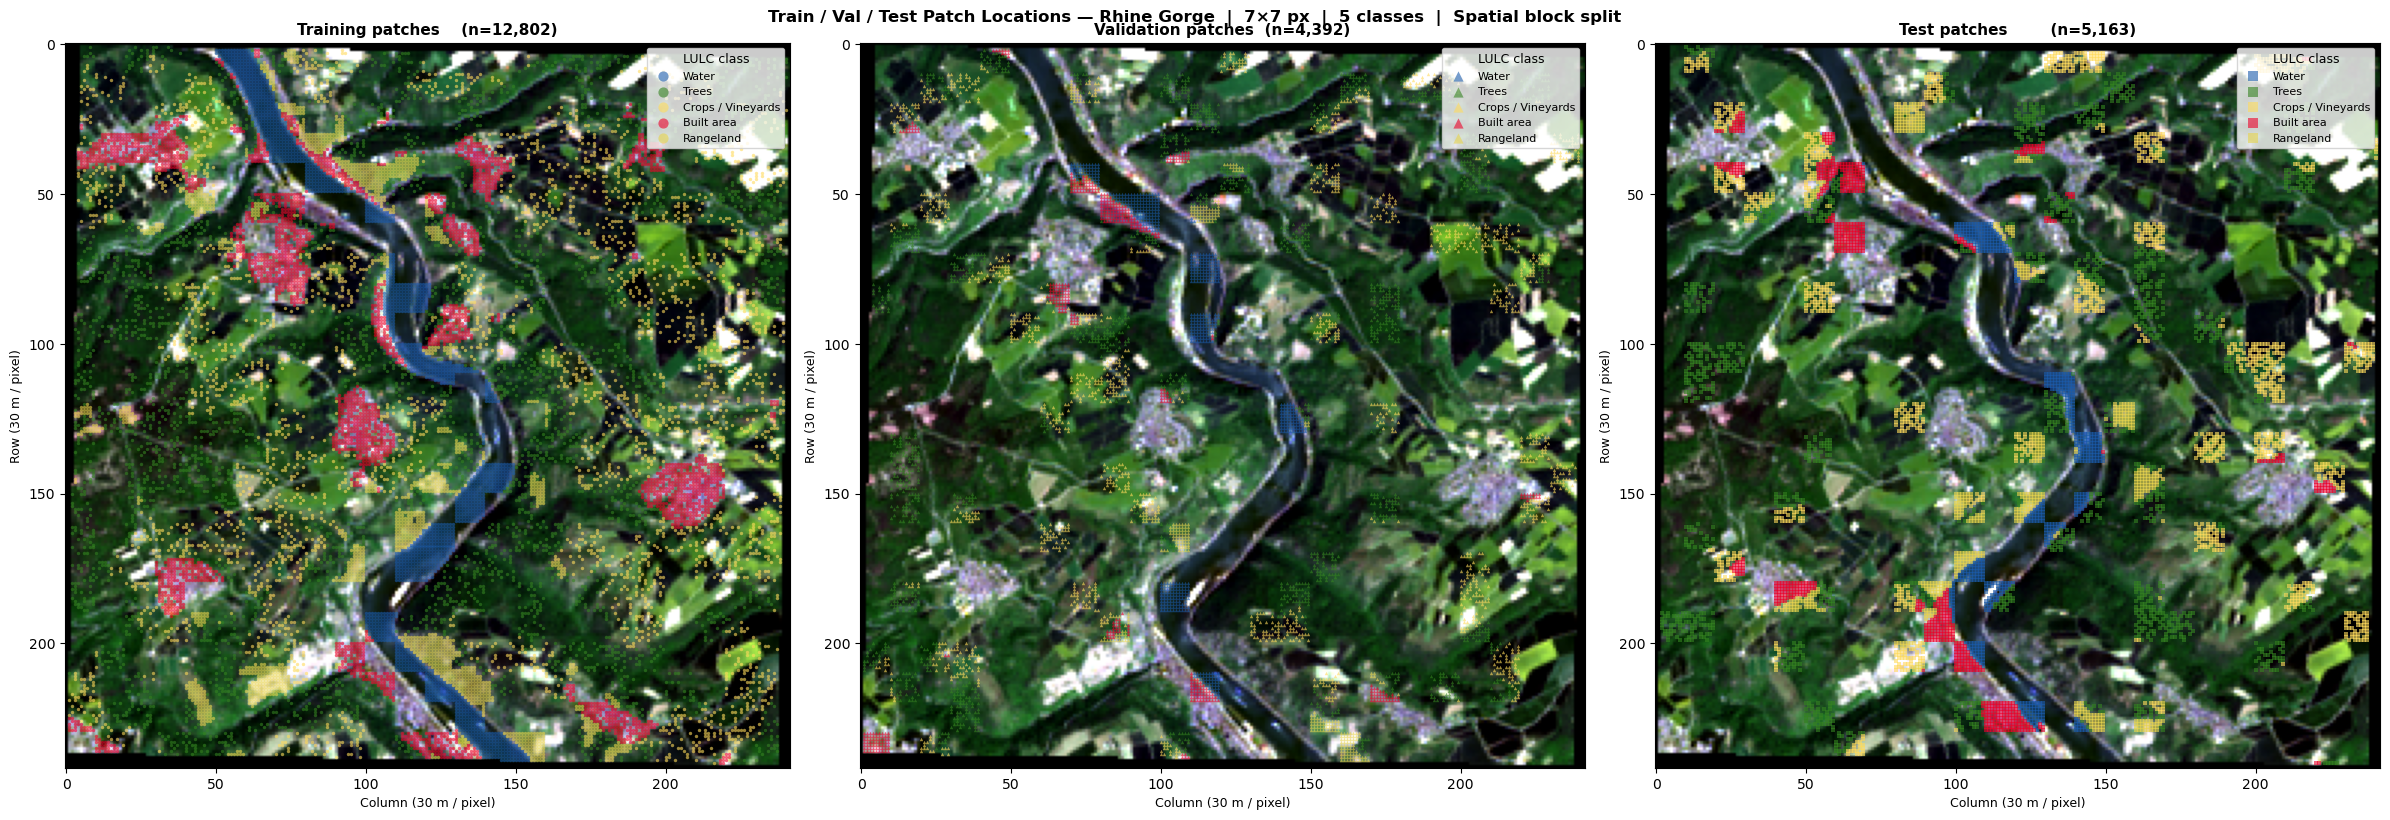

Saved → cnn_train_test_patches.png


In [7]:
def pct_stretch(band, lo=2, hi=98):
    v = band[~np.isnan(band)]
    p_lo, p_hi = np.percentile(v, lo), np.percentile(v, hi)
    return np.clip((band - p_lo) / (p_hi - p_lo + 1e-9), 0, 1)

rgb = np.nan_to_num(np.dstack([pct_stretch(b4), pct_stretch(b3), pct_stretch(b2)]), nan=0.0)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (c_plot, y_plot, title, marker) in zip(axes, [
    (c_train, y_train, f'Training patches    (n={len(c_train):,})',  'o'),
    (c_val,   y_val,   f'Validation patches  (n={len(c_val):,})',    '^'),
    (c_test,  y_test,  f'Test patches        (n={len(c_test):,})',   's'),
]):
    ax.imshow(rgb.astype(np.float32))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Column (30 m / pixel)', fontsize=9)
    ax.set_ylabel('Row (30 m / pixel)', fontsize=9)
    for esri_code, (name, color, cnn_label) in CLASS_MAP.items():
        mask = y_plot == cnn_label
        if mask.sum() == 0: continue
        ax.scatter(c_plot[mask, 1], c_plot[mask, 0],
                   c=color, s=6, marker=marker, alpha=0.6, label=name, linewidths=0)
    ax.legend(title='LULC class', fontsize=8, title_fontsize=9,
              loc='upper right', framealpha=0.8, markerscale=3)

fig.suptitle(
    f'Train / Val / Test Patch Locations — Rhine Gorge  |  '    f'{PATCH_SIZE}×{PATCH_SIZE} px  |  {N_CLASSES} classes  |  Spatial block split',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_train_test_patches.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_train_test_patches.png')


## Step 6 — CNN architecture  *(Assessment 4c)*

In [8]:
class PatchCNN(nn.Module):
    """
    Patch-based CNN for LULC classification.
    Input  : (batch, N_CHANNELS, PATCH_SIZE, PATCH_SIZE)
    Output : (batch, N_CLASSES)

    Architecture:
      Block 1 — Conv 3×3 → BN → ReLU → Conv 3×3 → BN → ReLU
      Block 2 — MaxPool → Conv 3×3 → BN → ReLU
      Block 3 — AdaptiveAvgPool → Flatten → FC(128) → ReLU → Dropout → FC(N_CLASSES)

    The extra FC(128) hidden layer (vs a direct projection) gives the model
    capacity to learn non-linear class boundaries in spectral feature space.
    """
    def __init__(self, n_channels, n_classes, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(n_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            # Block 2
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            # Global average pool → (batch, 128, 1, 1)
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128), nn.ReLU(inplace=True),  # hidden FC layer
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Verify architecture
demo      = PatchCNN(N_CHANNELS, N_CLASSES)
n_params  = sum(p.numel() for p in demo.parameters() if p.requires_grad)
dummy_in  = torch.zeros(4, N_CHANNELS, PATCH_SIZE, PATCH_SIZE)
dummy_out = demo(dummy_in)
print(f'CNN architecture verified')
print(demo)
print(f'\nInput  : {list(dummy_in.shape)}')
print(f'Output : {list(dummy_out.shape)}')
print(f'Trainable parameters: {n_params:,}')


CNN architecture verified
PatchCNN(
  (features): Sequential(
    (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128

## Step 7 — DataLoaders

In [9]:
class PatchDataset(Dataset):
    def __init__(self, patches, labels):
        self.X = torch.tensor(patches.transpose(0, 3, 1, 2), dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE   = 64
train_loader = DataLoader(PatchDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(PatchDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(PatchDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

# Class weights from TRAIN set only
class_counts  = np.bincount(y_train, minlength=N_CLASSES).astype(float)
class_weights = torch.tensor(1.0 / (class_counts + 1e-6), dtype=torch.float32).to(DEVICE)
class_weights /= class_weights.sum()

print(f'Train: {len(train_loader)} batches  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}')
print('Class weights (higher = rarer class):  ' +
      '  '.join(f'{CLASS_NAMES[i]}: {class_weights[i]:.3f}' for i in range(N_CLASSES)))


Train: 200 batches  |  Val: 69  |  Test: 81
Class weights (higher = rarer class):  Water: 0.246  Trees: 0.162  Crops / Vineyards: 0.162  Built area: 0.162  Rangeland: 0.267


## Step 8 — Hyperparameter tuning  *(Assessment 4b)*

Grid search over learning rate and dropout. Each config trained for 20 epochs; training curves plotted side by side for all combinations.

Hyperparameter grid (4 combinations × 20 epochs each)
LR       Dropout     Val Acc (%)
──────────────────────────────────
0.001    0.2               91.94%
0.0005   0.2               91.69%
0.001    0.4               91.71%
0.0005   0.4               91.64%

★  Best: LR=0.001, Dropout=0.2  →  Val Acc=91.94%


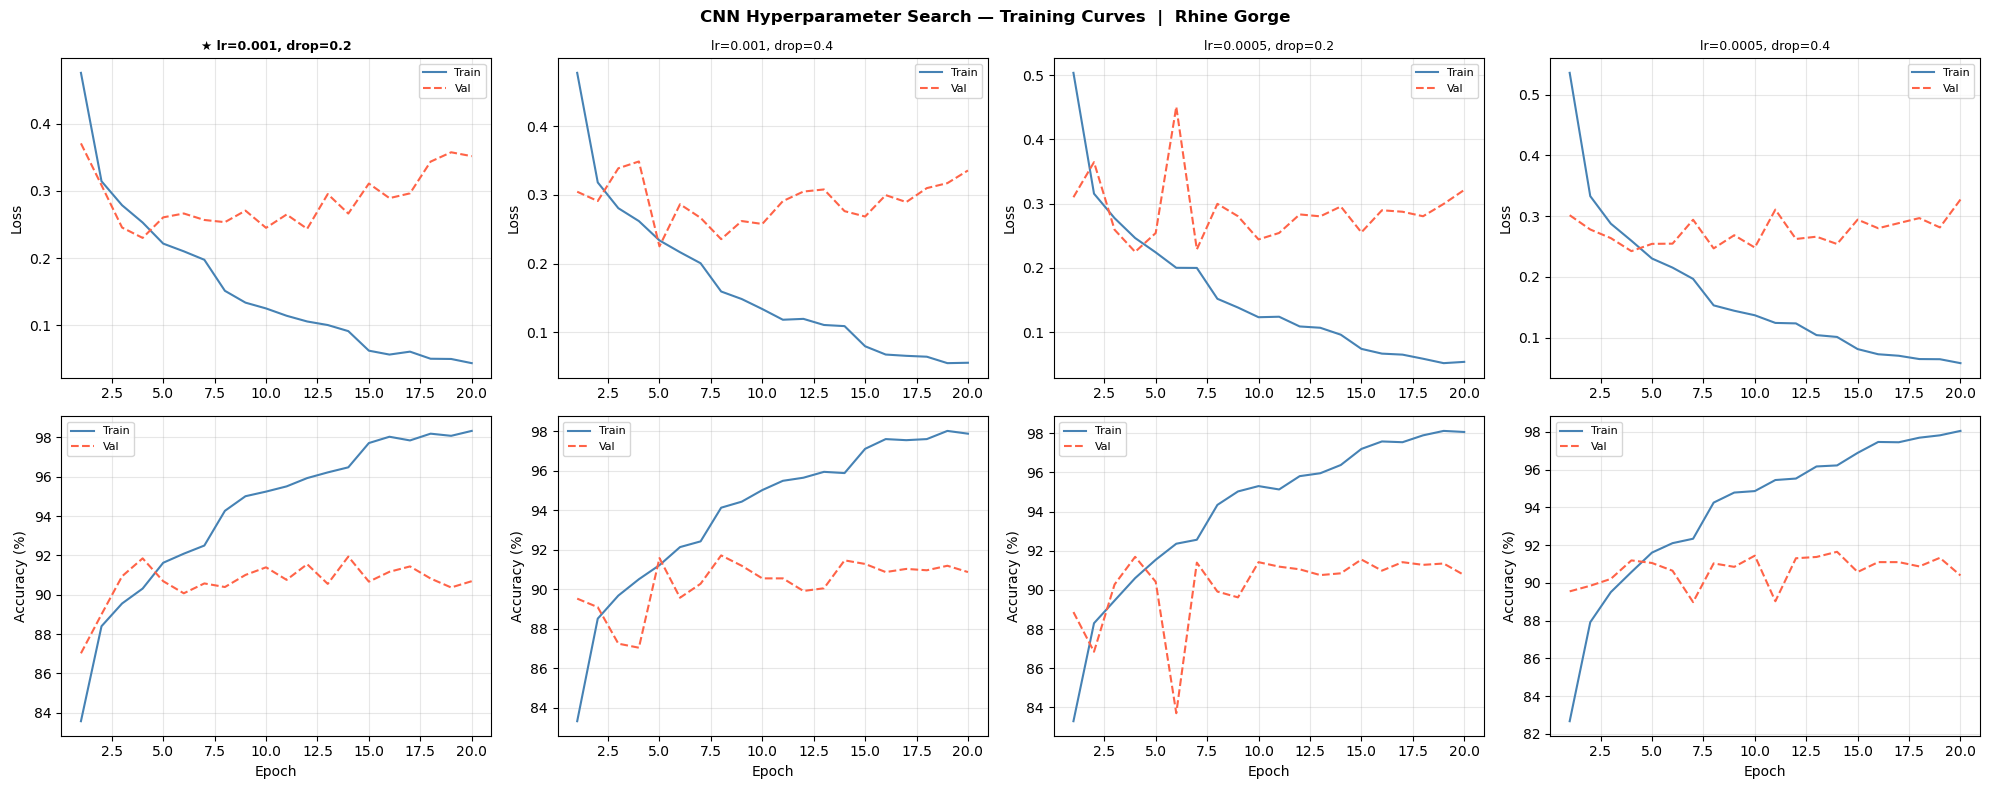

Saved → cnn_training_curves.png


In [ ]:
def run_epoch(model, loader, optimizer, criterion, scheduler=None, training=True):
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += len(yb)
    if training and scheduler is not None:
        scheduler.step()
    return total_loss / n, correct / n * 100   # return accuracy as %

HP_GRID     = list(ParameterGrid({'lr': [1e-3, 5e-4], 'dropout': [0.2, 0.4]}))
TUNE_EPOCHS = 20
hp_results  = []

print(f'Hyperparameter grid ({len(HP_GRID)} combinations × {TUNE_EPOCHS} epochs each)')
print(f'{"LR":<8} {"Dropout":<10} {"Val Acc (%)":>12}')
print('─' * 34)

for hp in HP_GRID:
    model_hp = PatchCNN(N_CHANNELS, N_CLASSES, dropout=hp['dropout']).to(DEVICE)
    opt_hp   = optim.Adam(model_hp.parameters(), lr=hp['lr'], weight_decay=1e-4)
    # StepLR: halve LR every 7 epochs — same schedule as friend's project
    sched_hp = optim.lr_scheduler.StepLR(opt_hp, step_size=7, gamma=0.5)
    crit_hp  = nn.CrossEntropyLoss(weight=class_weights)
    hist     = {'tr_loss': [], 'vl_loss': [], 'tr_acc': [], 'vl_acc': []}

    for ep in range(TUNE_EPOCHS):
        tr_l, tr_a = run_epoch(model_hp, train_loader, opt_hp, crit_hp,
                               scheduler=sched_hp, training=True)
        vl_l, vl_a = run_epoch(model_hp, val_loader,   opt_hp, crit_hp, training=False)
        hist['tr_loss'].append(tr_l); hist['vl_loss'].append(vl_l)
        hist['tr_acc'].append(tr_a);  hist['vl_acc'].append(vl_a)

    best_val = max(hist['vl_acc'])
    hp_results.append({'hp': hp, 'val_acc': best_val, 'history': hist})
    print(f'{hp["lr"]:<8} {hp["dropout"]:<10} {best_val:>12.2f}%')

hp_results.sort(key=lambda x: x['val_acc'], reverse=True)
BEST      = hp_results[0]
BEST_LR   = BEST['hp']['lr']
BEST_DROP = BEST['hp']['dropout']
print(f'\n★  Best: LR={BEST_LR}, Dropout={BEST_DROP}  →  Val Acc={BEST["val_acc"]:.2f}%')

#  Training curves for all HP combinations
fig, axes = plt.subplots(2, len(hp_results), figsize=(5 * len(hp_results), 8))
if len(hp_results) == 1: axes = axes.reshape(2, 1)

for col, res in enumerate(hp_results):
    hist      = res['history']
    ep        = range(1, len(hist['tr_loss']) + 1)
    label_str = f'lr={res["hp"]["lr"]}, drop={res["hp"]["dropout"]}'
    is_best   = (res is BEST)

    axes[0, col].plot(ep, hist['tr_loss'], color='steelblue', lw=1.5, label='Train')
    axes[0, col].plot(ep, hist['vl_loss'], color='tomato',    lw=1.5, label='Val', ls='--')
    axes[0, col].set_title(('★ ' if is_best else '') + label_str, fontsize=9,
                            fontweight='bold' if is_best else 'normal')
    axes[0, col].set_ylabel('Loss'); axes[0, col].legend(fontsize=8); axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(ep, hist['tr_acc'], color='steelblue', lw=1.5, label='Train')
    axes[1, col].plot(ep, hist['vl_acc'], color='tomato',    lw=1.5, label='Val', ls='--')
    axes[1, col].set_ylabel('Accuracy (%)'); axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend(fontsize=8); axes[1, col].grid(alpha=0.3)

fig.suptitle('CNN Hyperparameter Search — Training Curves  |  Rhine Gorge',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_training_curves.png')


## Step 9 — Train best model to convergence  *(Assessment 4c)*

Training best CNN  (LR=0.001, Dropout=0.2, L2=1e-4, max 60 epochs)
Epoch   Tr Loss      Tr Acc %     Val Loss     Val Acc %
──────────────────────────────────────────────────────────
1       0.4669       84.0         0.3779       87.1
5       0.2248       91.5         0.2539       90.6
10      0.1293       95.1         0.2822       90.7
15      0.0732       97.3         0.3103       90.1
Early stopping at epoch 17.

Best validation accuracy: 91.73%


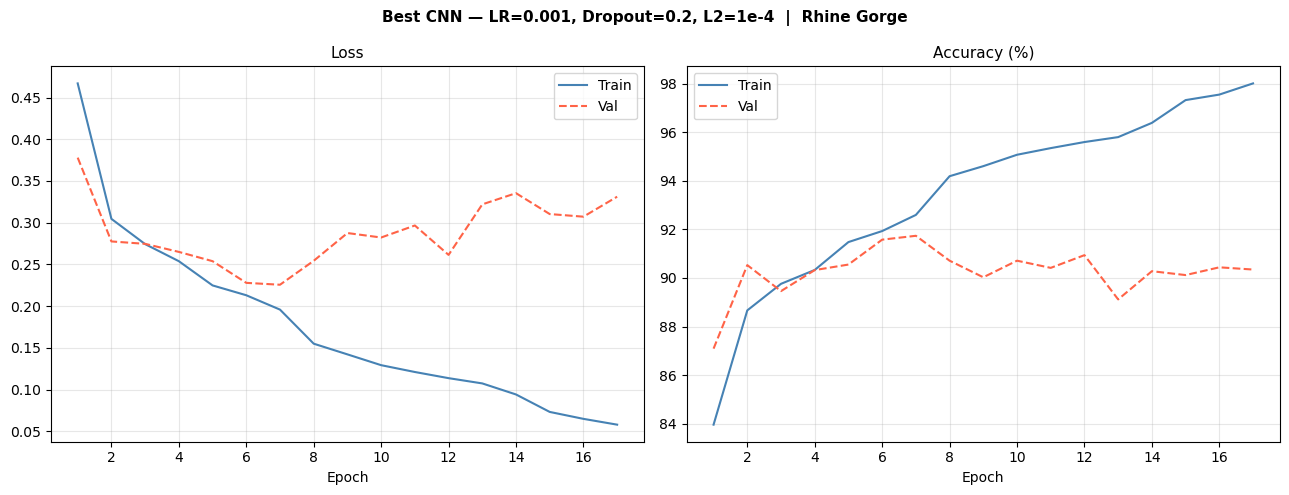

Saved → cnn_best_training_curve.png


In [11]:
MAX_EPOCHS = 60
PATIENCE   = 10

model     = PatchCNN(N_CHANNELS, N_CLASSES, dropout=BEST_DROP).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR, weight_decay=1e-4)
# StepLR consistent with HP tuning schedule
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_val_acc, patience_count, best_weights = 0.0, 0, None
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Training best CNN  (LR={BEST_LR}, Dropout={BEST_DROP}, L2=1e-4, max {MAX_EPOCHS} epochs)')
print(f'{"Epoch":<7} {"Tr Loss":<12} {"Tr Acc %":<12} {"Val Loss":<12} {"Val Acc %"}')
print('─' * 58)

for epoch in range(1, MAX_EPOCHS + 1):
    tr_l, tr_a = run_epoch(model, train_loader, optimizer, criterion,
                           scheduler=scheduler, training=True)
    vl_l, vl_a = run_epoch(model, val_loader,   optimizer, criterion, training=False)
    history['train_loss'].append(tr_l); history['val_loss'].append(vl_l)
    history['train_acc'].append(tr_a);  history['val_acc'].append(vl_a)

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:<7} {tr_l:<12.4f} {tr_a:<12.1f} {vl_l:<12.4f} {vl_a:.1f}')

    if vl_a > best_val_acc:
        best_val_acc   = vl_a
        best_weights   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.'); break

model.load_state_dict(best_weights)
print(f'\nBest validation accuracy: {best_val_acc:.2f}%')

# Final learning curve 
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ep, history['train_loss'], color='steelblue', lw=1.5, label='Train')
axes[0].plot(ep, history['val_loss'],   color='tomato',    lw=1.5, label='Val', ls='--')
axes[0].set_title('Loss', fontsize=11); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], color='steelblue', lw=1.5, label='Train')
axes[1].plot(ep, history['val_acc'],   color='tomato',    lw=1.5, label='Val', ls='--')
axes[1].set_title('Accuracy (%)', fontsize=11); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f'Best CNN — LR={BEST_LR}, Dropout={BEST_DROP}, L2=1e-4  |  Rhine Gorge',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_best_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_best_training_curve.png')


## Step 10 — Full AOI prediction and map

Predicting full AOI...
Done — prediction map: (242, 242)


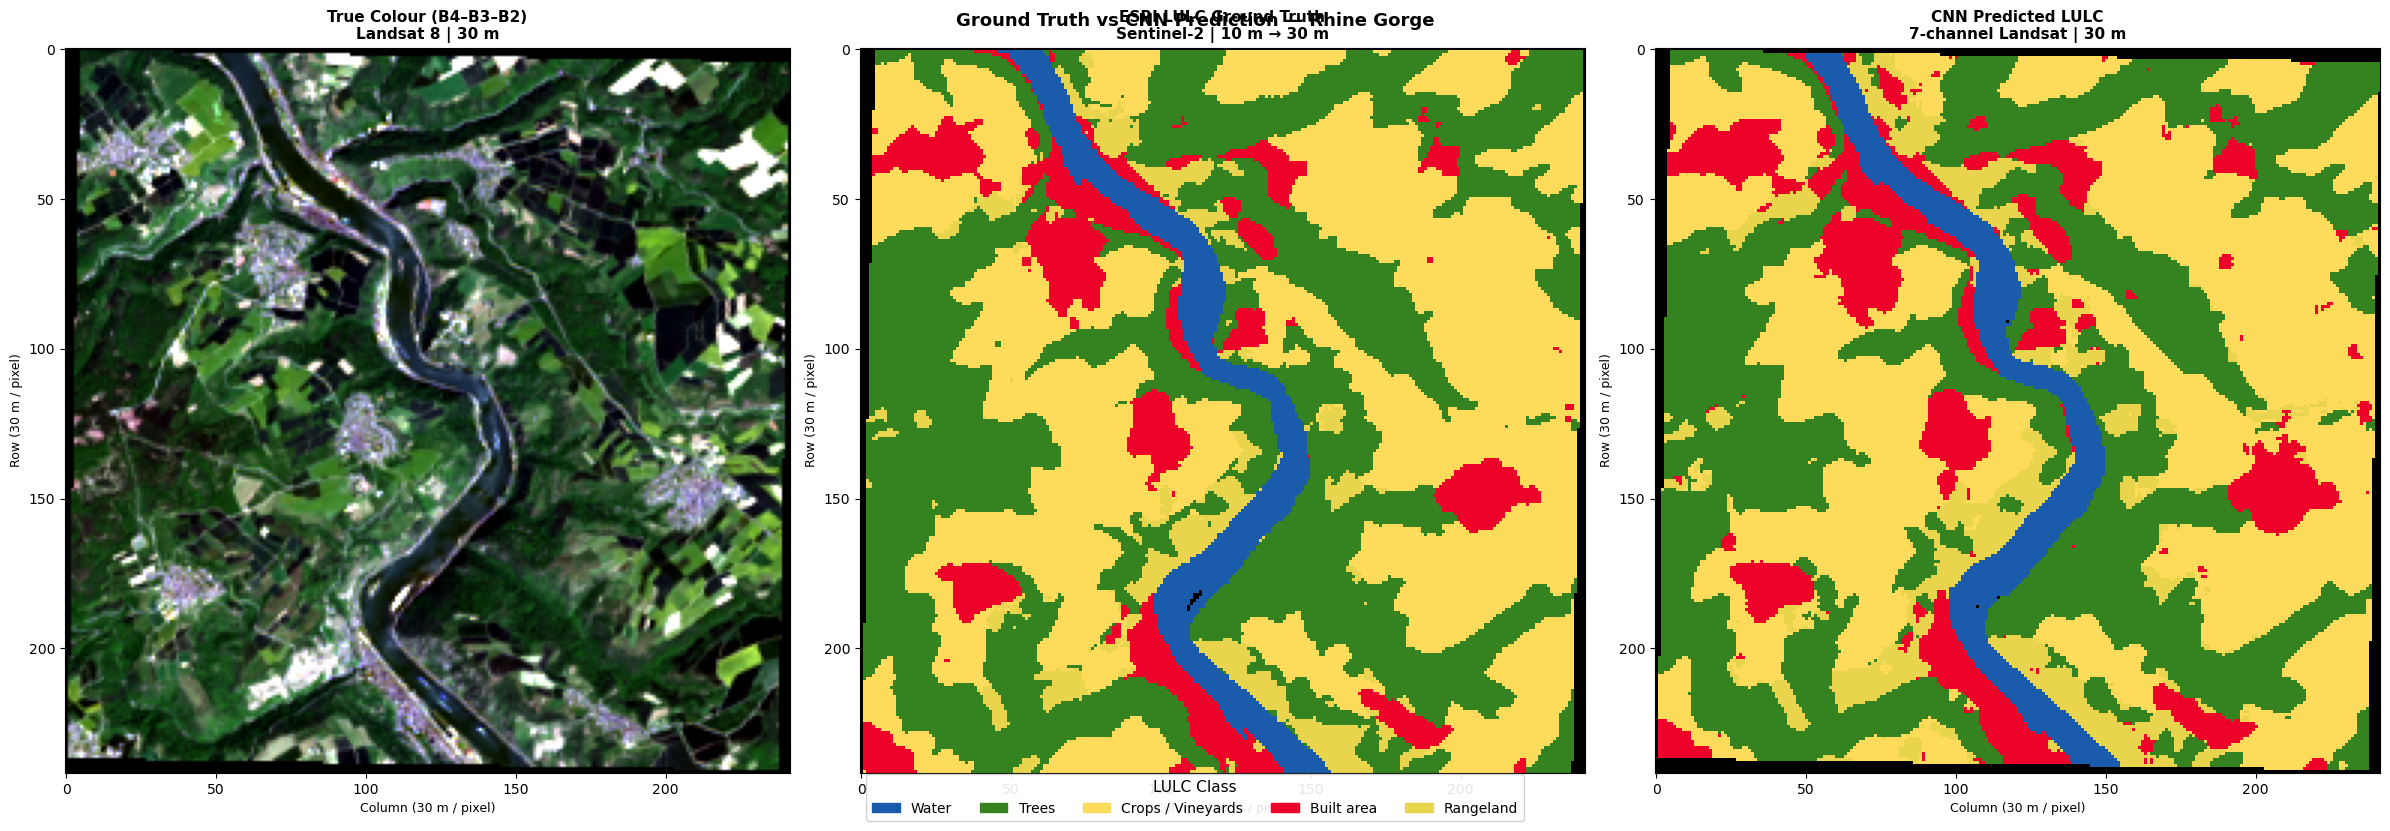

Saved → cnn_prediction_map.png


In [12]:
@torch.no_grad()
def predict_full_scene(model, band_stack, patch_size, ch_mean, ch_std, batch_size=512):
    H, W, C  = band_stack.shape
    half     = patch_size // 2
    padded   = np.pad(band_stack, ((half, half), (half, half), (0, 0)), mode='reflect')
    pred_map = np.full((H, W), -1, dtype=np.int8)
    ys, xs   = np.where(~np.isnan(band_stack[:, :, 3]))   # valid NIR pixels
    model.eval()
    for start in range(0, len(ys), batch_size):
        by = ys[start:start + batch_size]
        bx = xs[start:start + batch_size]
        p  = np.stack([padded[y:y+patch_size, x:x+patch_size, :]
                       for y, x in zip(by, bx)]).astype(np.float32)
        p  = np.nan_to_num((p - ch_mean) / ch_std, nan=0.0)
        t  = torch.tensor(p.transpose(0, 3, 1, 2)).to(DEVICE)
        pred_map[by, bx] = model(t).cpu().numpy().argmax(axis=1)
    return pred_map

print('Predicting full AOI...')
PRED_MAP = predict_full_scene(model, BAND_STACK, PATCH_SIZE, CHANNEL_MEAN, CHANNEL_STD)
print(f'Done — prediction map: {PRED_MAP.shape}')

#Build colour maps 
# CNN label order (0-indexed as in CLASS_MAP cnn_label)
cnn_colors = [CLASS_MAP[k][1] for k in sorted(CLASS_MAP, key=lambda k: CLASS_MAP[k][2])]
cnn_cmap   = mcolors.ListedColormap(['#000000'] + cnn_colors)
cnn_norm   = mcolors.BoundaryNorm([-1] + list(range(N_CLASSES + 1)), cnn_cmap.N)

# ESRI ground-truth colour map (same class order)
esri_cmap  = mcolors.ListedColormap(['#000000'] + cnn_colors)
esri_norm  = cnn_norm

# Remap lulc_labels (ESRI codes) → CNN label indices for display
lulc_display = np.full_like(lulc_labels, -1)
for esri_code, (_, _, cnn_lbl) in CLASS_MAP.items():
    lulc_display[lulc_labels == cnn_lbl] = cnn_lbl   # lulc_labels already mapped in Cell 8

legend_patches = [
    mpatches.Patch(color=CLASS_MAP[k][1], label=CLASS_MAP[k][0])
    for k in sorted(CLASS_MAP, key=lambda k: CLASS_MAP[k][2])
]

# Side-by-side: True colour | Ground truth | Prediction 
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].imshow(rgb.astype(np.float32))
axes[0].set_title('True Colour (B4–B3–B2)\nLandsat 8 | 30 m', fontsize=11, fontweight='bold')

axes[1].imshow(lulc_display, cmap=esri_cmap, norm=esri_norm, interpolation='nearest')
axes[1].set_title('ESRI LULC Ground Truth\nSentinel-2 | 10 m → 30 m', fontsize=11, fontweight='bold')

axes[2].imshow(PRED_MAP, cmap=cnn_cmap, norm=cnn_norm, interpolation='nearest')
axes[2].set_title('CNN Predicted LULC\n7-channel Landsat | 30 m', fontsize=11, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Column (30 m / pixel)', fontsize=9)
    ax.set_ylabel('Row (30 m / pixel)', fontsize=9)

fig.legend(handles=legend_patches, loc='lower center', ncol=N_CLASSES,
           fontsize=10, title='LULC Class', title_fontsize=11,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

fig.suptitle('Ground Truth vs CNN Prediction — Rhine Gorge',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_prediction_map.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_prediction_map.png')


---
# Task 5 — Accuracy Metrics

All metrics computed on the held-out **test set** only.

## Step 11 — Test set predictions

In [13]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    preds, probs, true_labels = [], [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        p      = torch.softmax(logits, dim=1).cpu().numpy()
        probs.append(p); preds.append(p.argmax(axis=1)); true_labels.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(probs), np.concatenate(true_labels)

y_pred, y_prob, y_true = get_predictions(model, test_loader)
overall_acc = (y_pred == y_true).mean() * 100
print(f'Test accuracy : {overall_acc:.2f}%  |  Test samples: {len(y_true):,}')
print()
print(classification_report(y_true, y_pred, labels=list(range(N_CLASSES)),
                             target_names=CLASS_NAMES, digits=4, zero_division=0))

Test accuracy : 88.07%  |  Test samples: 5,163

                   precision    recall  f1-score   support

            Water     0.9623    0.9580    0.9602       667
            Trees     0.9450    0.9053    0.9248      1500
Crops / Vineyards     0.9454    0.8200    0.8783      1500
       Built area     0.7994    0.9581    0.8716       836
        Rangeland     0.6838    0.7864    0.7315       660

         accuracy                         0.8807      5163
        macro avg     0.8672    0.8856    0.8733      5163
     weighted avg     0.8904    0.8807    0.8825      5163



## Step 12 — Confusion matrix  *(Assessment 5)*

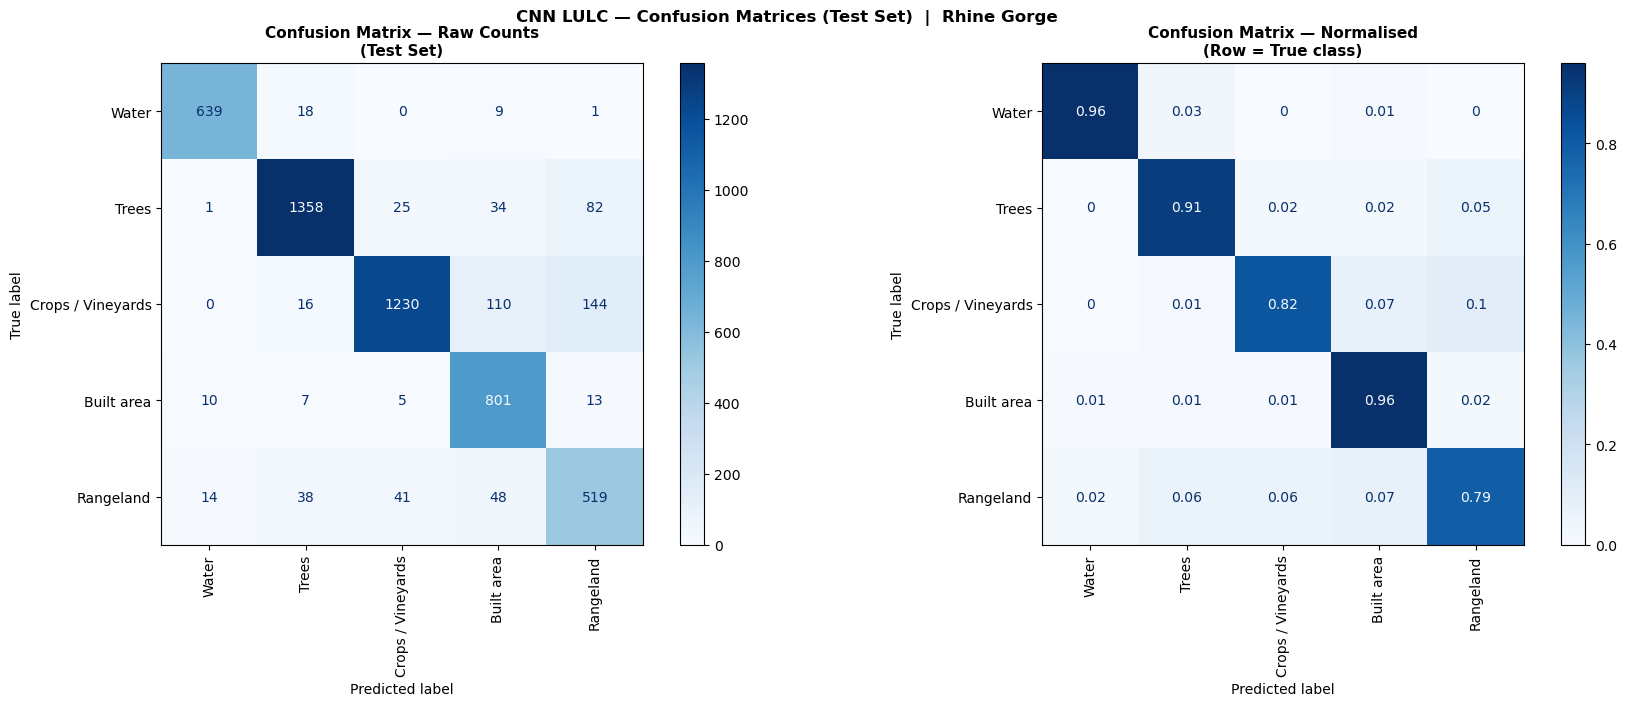

Saved → cnn_confusion_matrix.png


In [14]:
cm      = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap='Blues', colorbar=True, xticks_rotation='vertical')
axes[0].set_title('Confusion Matrix — Raw Counts\n(Test Set)', fontsize=11, fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 2),
                       display_labels=CLASS_NAMES).plot(
    ax=axes[1], cmap='Blues', colorbar=True, xticks_rotation='vertical')
axes[1].set_title('Confusion Matrix — Normalised\n(Row = True class)', fontsize=11, fontweight='bold')

fig.suptitle('CNN LULC — Confusion Matrices (Test Set)  |  Rhine Gorge',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_confusion_matrix.png')


## Step 13 — F1 and IoU scores  *(Assessment 5)*

Class                         F1     IoU
──────────────────────────────────────────
Water                     0.9602  0.9234  ███████████████████
Trees                     0.9248  0.8600  ██████████████████
Crops / Vineyards         0.8783  0.7829  █████████████████
Built area                0.8716  0.7724  █████████████████
Rangeland                 0.7315  0.5767  ██████████████
──────────────────────────────────────────
Macro average             0.8733  0.7831
Weighted average          0.8825


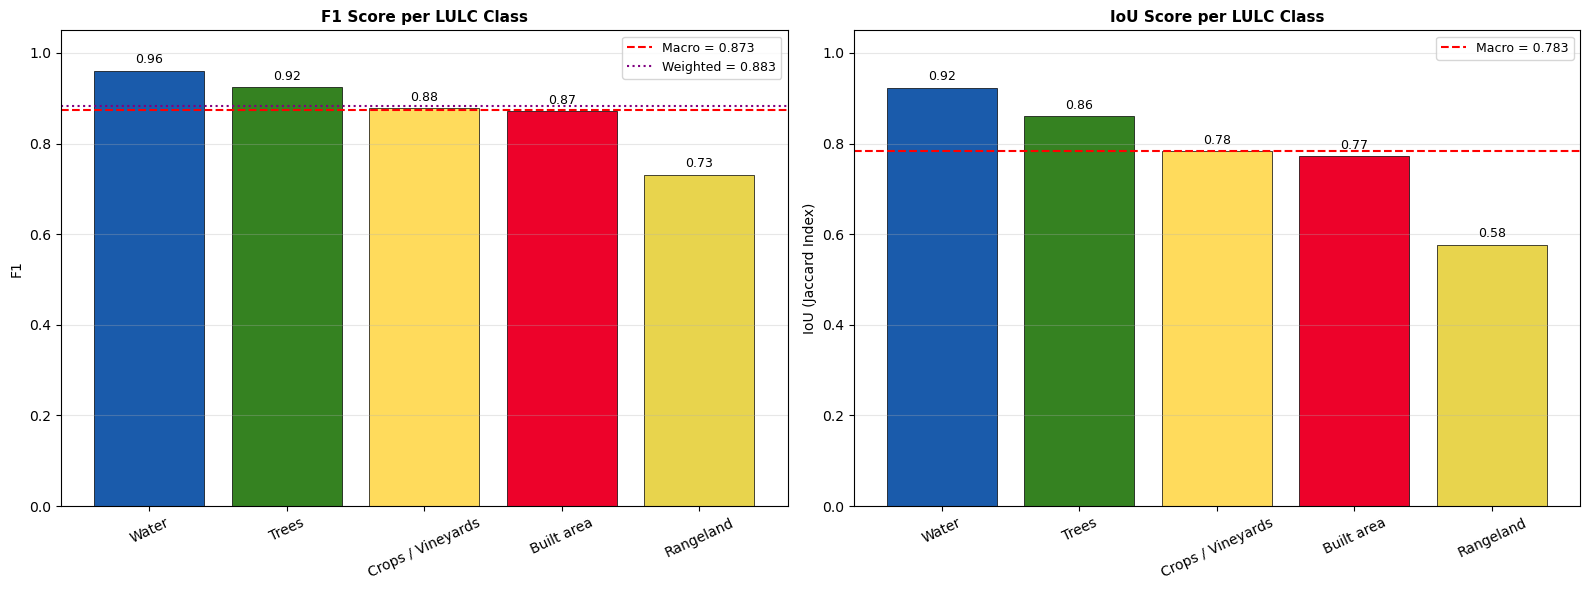

Saved → cnn_f1_iou.png


In [15]:
f1_per_class  = f1_score(y_true, y_pred, average=None,
                         labels=range(N_CLASSES), zero_division=0)
f1_macro      = f1_score(y_true, y_pred, average='macro',
                         labels=range(N_CLASSES), zero_division=0)
f1_weighted   = f1_score(y_true, y_pred, average='weighted',
                         labels=range(N_CLASSES), zero_division=0)
iou_per_class = jaccard_score(y_true, y_pred, average=None,
                              labels=range(N_CLASSES), zero_division=0)
iou_macro     = jaccard_score(y_true, y_pred, average='macro',
                              labels=range(N_CLASSES), zero_division=0)

print(f'{"Class":<24} {"F1":>7} {"IoU":>7}')
print('─' * 42)
for i, name in enumerate(CLASS_NAMES):
    bar = '█' * int(f1_per_class[i] * 20)
    print(f'{name:<24} {f1_per_class[i]:>7.4f} {iou_per_class[i]:>7.4f}  {bar}')
print('─' * 42)
print(f'{"Macro average":<24} {f1_macro:>7.4f} {iou_macro:>7.4f}')
print(f'{"Weighted average":<24} {f1_weighted:>7.4f}')

#Bar charts 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, vals, title, ylabel, macro, weighted in [
    (axes[0], f1_per_class,  'F1 Score per LULC Class',  'F1',
     f1_macro, f1_weighted),
    (axes[1], iou_per_class, 'IoU Score per LULC Class', 'IoU (Jaccard Index)',
     iou_macro, None),
]:
    bars = ax.bar(CLASS_NAMES, vals, color=CLASS_COLORS,
                  edgecolor='k', linewidth=0.5)
    ax.axhline(macro, color='red',  ls='--', lw=1.5, label=f'Macro = {macro:.3f}')
    if weighted:
        ax.axhline(weighted, color='purple', ls=':', lw=1.5,
                   label=f'Weighted = {weighted:.3f}')
    ax.set_ylim(0, 1.05); ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_f1_iou.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cnn_f1_iou.png')


## Step 14 — ROC curves  *(Assessment 5)*

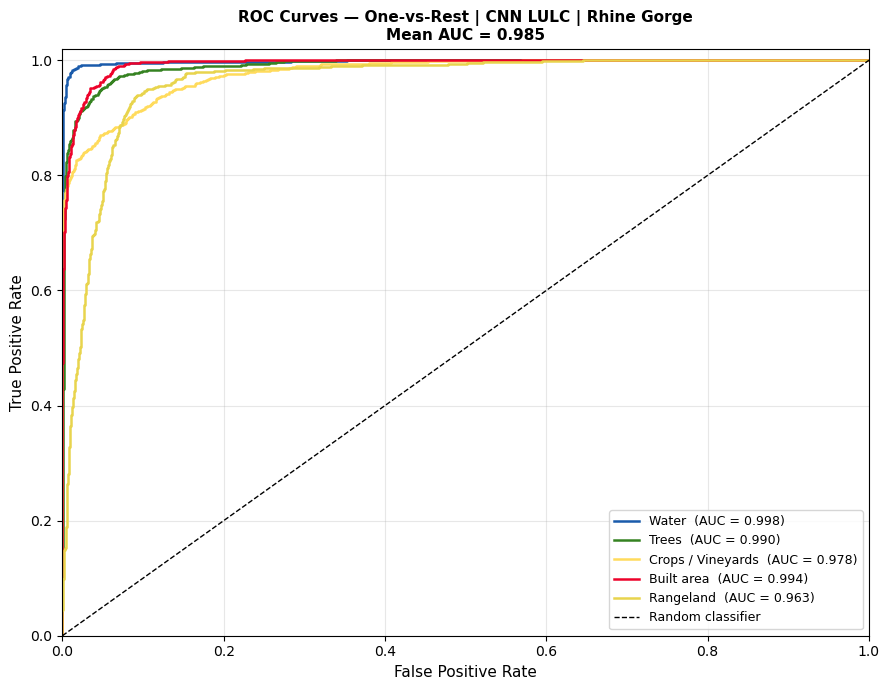

AUC per class:
  Water                   : 0.9980  ███████████████████
  Built area              : 0.9935  ███████████████████
  Trees                   : 0.9905  ███████████████████
  Crops / Vineyards       : 0.9781  ███████████████████
  Rangeland               : 0.9628  ███████████████████
  Mean AUC: 0.9846
Saved → cnn_roc_curves.png


In [16]:
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=range(N_CLASSES))
fig, ax    = plt.subplots(figsize=(9, 7))
roc_aucs   = {}

for i, name in enumerate(CLASS_NAMES):
    if y_true_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc      = auc(fpr, tpr)
    roc_aucs[name] = roc_auc
    ax.plot(fpr, tpr, lw=1.8, color=CLASS_COLORS[i],
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
mean_auc = np.mean(list(roc_aucs.values()))
ax.set_title(f'ROC Curves — One-vs-Rest | CNN LULC | Rhine Gorge\n'             f'Mean AUC = {mean_auc:.3f}', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print('AUC per class:')
for cls, sc in sorted(roc_aucs.items(), key=lambda x: -x[1]):
    bar = '█' * int(sc * 20)
    print(f'  {cls:<24}: {sc:.4f}  {bar}')
print(f'  Mean AUC: {mean_auc:.4f}')
print('Saved → cnn_roc_curves.png')


## Step 15 — Final summary

In [17]:
print('=' * 58)
print('  CNN LULC — Final Accuracy Summary')
print('=' * 58)
print(f'  Scene              : {SCENE_ID}')
print(f'  Best HP            : LR={BEST_LR}, Dropout={BEST_DROP}')
print(f'  Channels           : {N_CHANNELS} (B2–B7 + NDVI)')
print(f'  Patch size         : {PATCH_SIZE}×{PATCH_SIZE} px')
print(f'  Split              : 70/15/15 spatial block split')
print(f'  Test samples       : {len(y_true):,}')
print('─' * 58)
print(f'  Overall Accuracy   : {overall_acc:.2f}%')
print(f'  Macro F1           : {f1_macro:.4f}')
print(f'  Weighted F1        : {f1_weighted:.4f}')
print(f'  Mean IoU (mIoU)    : {iou_macro:.4f}')
print(f'  Mean AUC (OvR)     : {mean_auc:.4f}')
print('=' * 58)
print()
print('Per-class breakdown:')
print(f'{"Class":<24} {"F1":>6} {"IoU":>6} {"AUC":>6}')
print('─' * 46)
for i, name in enumerate(CLASS_NAMES):
    auc_val = roc_aucs.get(name, float('nan'))
    print(f'  {name:<22} {f1_per_class[i]:>6.3f} '          f'{iou_per_class[i]:>6.3f} {auc_val:>6.3f}')
print()
print(f'All output files saved in: {OUTPUTS_DIR}')
for fname in sorted(os.listdir(OUTPUTS_DIR)):
    print(f'  {fname}')


  CNN LULC — Final Accuracy Summary
  Scene              : LC81960252021153LGN00
  Best HP            : LR=0.001, Dropout=0.2
  Channels           : 7 (B2–B7 + NDVI)
  Patch size         : 7×7 px
  Split              : 70/15/15 spatial block split
  Test samples       : 5,163
──────────────────────────────────────────────────────────
  Overall Accuracy   : 88.07%
  Macro F1           : 0.8733
  Weighted F1        : 0.8825
  Mean IoU (mIoU)    : 0.7831
  Mean AUC (OvR)     : 0.9846

Per-class breakdown:
Class                        F1    IoU    AUC
──────────────────────────────────────────────
  Water                   0.960  0.923  0.998
  Trees                   0.925  0.860  0.990
  Crops / Vineyards       0.878  0.783  0.978
  Built area              0.872  0.772  0.994
  Rangeland               0.732  0.577  0.963

All output files saved in: ../data/outputs
  cnn_best_training_curve.png
  cnn_confusion_matrix.png
  cnn_confusion_matrix_4x4.png
  cnn_f1_iou.png
  cnn_predicted_lulc